# 在线策略蒸馏（OPD）

> 传统蒸馏有一个隐藏的缺陷：Student 训练时只见过 Teacher 生成或数据集里的参考输出，从没见过自己犯错的样子。一旦推理时开始自己生成，遇到陌生的分布，可能质量下降。
>
> 这一节深入 On-Policy Distillation（OPD）的核心原理：让 Student 自己生成、Teacher 实时打分、Student 用反馈改进——训练数据的分布和 Student 自己的生成分布保持一致。

OPD 和传统蒸馏的本质区别在训练数据的来源。传统蒸馏的数据是 Teacher 自己写的（off-policy），无论 Student 怎么更新，训练数据都不变。

OPD 的数据由 Student 自己生成（on-policy）。Student 每轮先对 prompt 输出一个回答，Teacher 在 student 当前 prefix 上提供 token 分布、top-k、打分或文本反馈。Student 用这些信号更新自己，下一轮重新生成。

这个过程和 RLHF 的 PPO 结构很像——Student 是 Actor，Teacher 同时扮演 Reward Model 和 Reference Model。但 OPD 不一定需要单独训练 Reward Model；具体实现可能是 KL 蒸馏、SFT 式偏好数据、reward model 打分或带 KL 约束的目标，不能统一写成一种训练形式。

后训练不是在给模型「塞答案」，而是在重塑模型的**输出分布**。

语言模型本质上不是只会输出一个答案，而是在每个上下文里，对所有可能的下一个 token 分配概率。后训练就是把这个概率分布重新塑形：提高某些行为的概率，降低另一些行为的概率。

因此，比较 SFT、RL 和 OPD，最关键的不是问「有没有标签」或「有没有 reward」，而是问四个问题：

- 训练数据来自哪里（外部数据集 vs 模型自己生成）？
- 监督信号有多密集（逐 token vs 只给结果）？
- 目标分布离原模型有多远？
- 更新发生在模型自己真实会访问的状态上吗？

这四个问题，基本就能把三者的联系和区别讲清楚。下面用几个具体例子，把每种方法的分布移动方式演示出来。

## 模型输出分布

要理解 SFT、RL、OPD 的联系和区别，先从最基础的概念开始：**语言模型本质上是一个概率分布生成器**。给定一段上下文，模型会对词表中的每个 token 分配一个概率——这就是模型在这个上下文下的输出分布。

后训练做的事情，就是把这个概率分布重新塑形：提高某些行为的概率，降低另一些行为的概率。

先建立这个直观理解，再看三种方法各自怎么做。

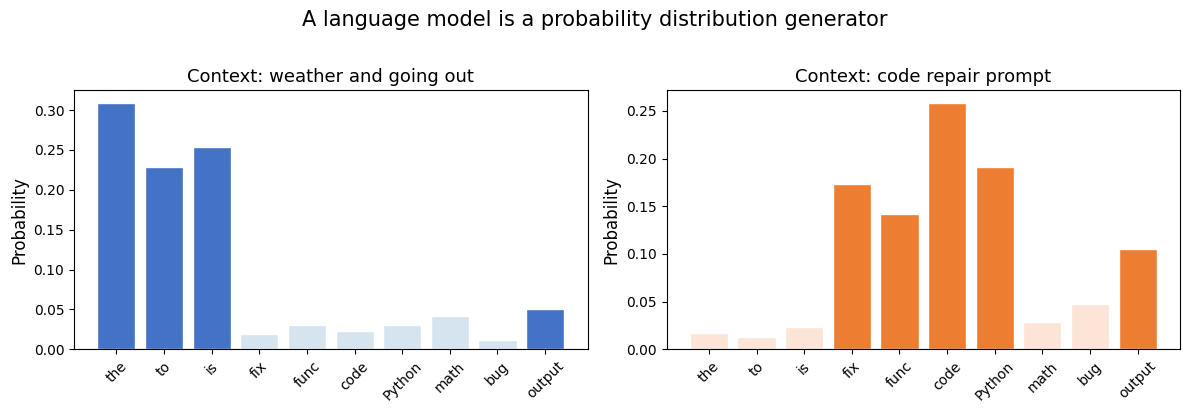

→ 同一个模型，不同上下文 → 输出概率分布会明显不同
→ 后训练就是：在特定上下文里，把分布重塑成我们想要的样子


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'

def softmax(logits):
    logits = np.array(logits, dtype=np.float64)
    e = np.exp(logits - logits.max())
    return e / e.sum()

# 小词表
vocab = ["the", "to", "is", "fix", "func", "code", "Python", "math", "bug", "output"]
vocab_size = len(vocab)

# 同一个模型，两个不同上下文的 logits
logits_chat = np.array([0.8, 0.5, 0.6, -2.0, -1.5, -1.8, -1.5, -1.2, -2.5, -1.0])
logits_code = np.array([-1.5, -1.8, -1.2, 0.8, 0.6, 1.2, 0.9, -1.0, -0.5, 0.3])

probs_chat = softmax(logits_chat)
probs_code = softmax(logits_code)

# 可视化：同一模型、不同上下文 → 完全不同分布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors_chat = ['#4472C4' if p > 0.05 else '#D6E4F0' for p in probs_chat]
ax1.bar(vocab, probs_chat, color=colors_chat, edgecolor='white')
ax1.set_title("Context: weather and going out", fontsize=13)
ax1.set_ylabel("Probability", fontsize=12)
ax1.tick_params(axis='x', rotation=45)

colors_code = ['#ED7D31' if p > 0.05 else '#FCE4D6' for p in probs_code]
ax2.bar(vocab, probs_code, color=colors_code, edgecolor='white')
ax2.set_title("Context: code repair prompt", fontsize=13)
ax2.set_ylabel("Probability", fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("A language model is a probability distribution generator", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"→ 同一个模型，不同上下文 → 输出概率分布会明显不同")
print(f"→ 后训练就是：在特定上下文里，把分布重塑成我们想要的样子")

## SFT：向外部数据分布模仿

SFT（Supervised Fine-Tuning）是最直观的后训练方法。先准备一个标注数据集，训练时模型看到 prompt 和标准答案，通过 Cross-Entropy 学习：在标准答案 token 出现的位置，提高模型生成它的概率。

从分布角度看，SFT 的目标分布来自外部数据集。它强在直接——尤其适合冷启动，当模型还不会遵循指令时，SFT 能迅速建立基本行为模板。

但 SFT 的风险也来自这里：标准答案里的每个 token 都会被当作学习目标——关键推理 token 要学，数据集里的风格词也要学，偶然表达和模板口癖也会被学进去。SFT loss 本身不知道这些差别，只会把整条答案都往上推。

=== SFT：向外部数据分布模仿 ===



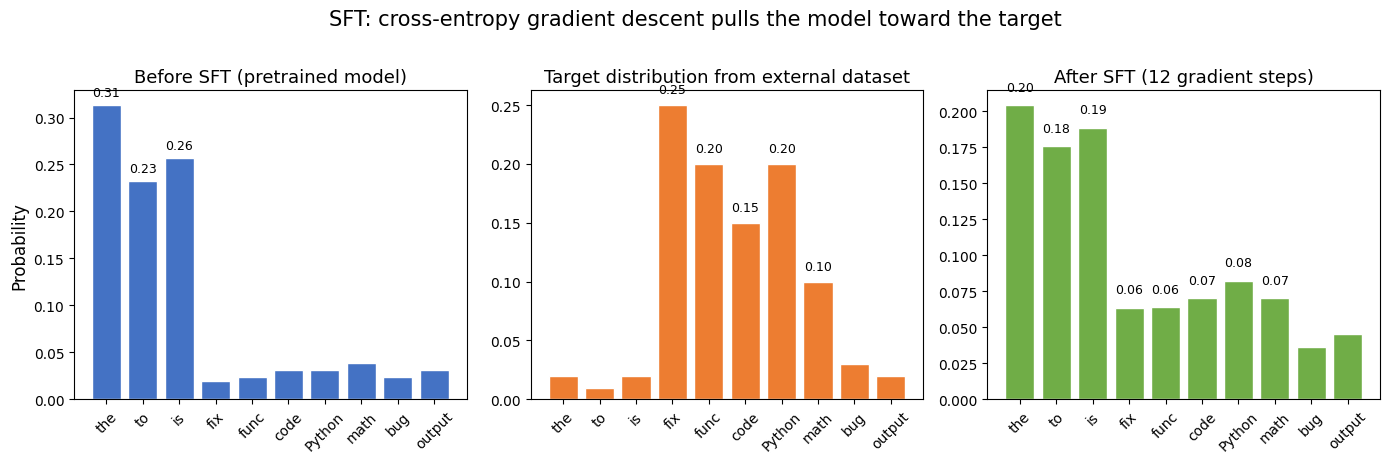

CE Loss: 3.5267 → 2.6463

关键观察：
  '修复' 概率: 0.019 → 0.064 (目标=0.250) ↑
  '代码' 概率: 0.031 → 0.070 (目标=0.150) ↑
  '的' 概率:   0.313 → 0.204 (目标=0.020) ↓

→ SFT 把整个分布拉向外部数据——任务 token 概率上升，通用高频词被压低
→ 风险：外部数据里的所有 token（包括风格词、偶然表达）都会被同等对待
→ 如果外部分布离原模型很远，旧能力可能被覆盖（灾难性遗忘）


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# === SFT：模拟 CE 梯度下降，把模型分布拉向外部目标分布 ===
print("=== SFT：向外部数据分布模仿 ===\n")

# 预训练模型在某个代码修复上下文的输出分布（偏向通用高频词）
init_logits = np.array([1.8, 1.5, 1.6, -1.0, -0.8, -0.5, -0.5, -0.3, -0.8, -0.5])
init_model = softmax(init_logits)

# 外部标注数据给出的目标分布（任务相关 token 概率更高）
target = np.array([0.02, 0.01, 0.02, 0.25, 0.20, 0.15, 0.20, 0.10, 0.03, 0.02])

# 模拟 CE 梯度下降：dCE/dlogits = softmax(logits) - target
model_logits = init_logits.copy()
lr = 0.3
steps = 12
history = [softmax(model_logits)]

for step in range(steps):
    model_probs = softmax(model_logits)
    grad = model_probs - target          # CE 对 logits 的梯度
    model_logits = model_logits - lr * grad  # 梯度下降
    history.append(softmax(model_logits))

final_model = history[-1]

# 可视化：SFT 前 vs 目标分布 vs SFT 后
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].bar(vocab, init_model, color='#4472C4', edgecolor='white')
axes[0].set_title('Before SFT (pretrained model)', fontsize=13)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(init_model):
    if v > 0.05:
        axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

axes[1].bar(vocab, target, color='#ED7D31', edgecolor='white')
axes[1].set_title('Target distribution from external dataset', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(target):
    if v > 0.05:
        axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

axes[2].bar(vocab, final_model, color='#70AD47', edgecolor='white')
axes[2].set_title(f'After SFT ({steps} gradient steps)', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(final_model):
    if v > 0.05:
        axes[2].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('SFT: cross-entropy gradient descent pulls the model toward the target', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 打印关键变化
ce_init = -np.sum(target * np.log(init_model + 1e-10))
ce_final = -np.sum(target * np.log(final_model + 1e-10))
print(f"CE Loss: {ce_init:.4f} → {ce_final:.4f}")
print(f"\n关键观察：")
print(f"  '修复' 概率: {init_model[3]:.3f} → {final_model[3]:.3f} (目标={target[3]:.3f}) ↑")
print(f"  '代码' 概率: {init_model[5]:.3f} → {final_model[5]:.3f} (目标={target[5]:.3f}) ↑")
print(f"  '的' 概率:   {init_model[0]:.3f} → {final_model[0]:.3f} (目标={target[0]:.3f}) ↓")
print(f"\n→ SFT 把整个分布拉向外部数据——任务 token 概率上升，通用高频词被压低")
print(f"→ 风险：外部数据里的所有 token（包括风格词、偶然表达）都会被同等对待")
print(f"→ 如果外部分布离原模型很远，旧能力可能被覆盖（灾难性遗忘）")

## RL：在自身行为中筛选高价值方向

RL 的训练逻辑与 SFT 完全不同。模型先从当前策略中自己生成回答，然后 reward function 给这些回答打分——高 reward 的回答以后更可能生成，低 reward 的被削弱。

关键差异在于：RL 的样本来自模型自己当前会生成的分布，而不是外部数据集。这表示 RL **不是把模型拉向一个任意远的外部数据分布，而是在模型自己会访问的区域里，把概率质量推向更高 reward 的行为**。

这也是 RL 更不容易遗忘的原因。但它有一个明显的问题：reward 往往很稀疏——一道题答错了，只知道整条轨迹不好，却不一定知道是哪一步出错。

=== RL：在模型自己生成的行为里筛选高 reward 方向 ===



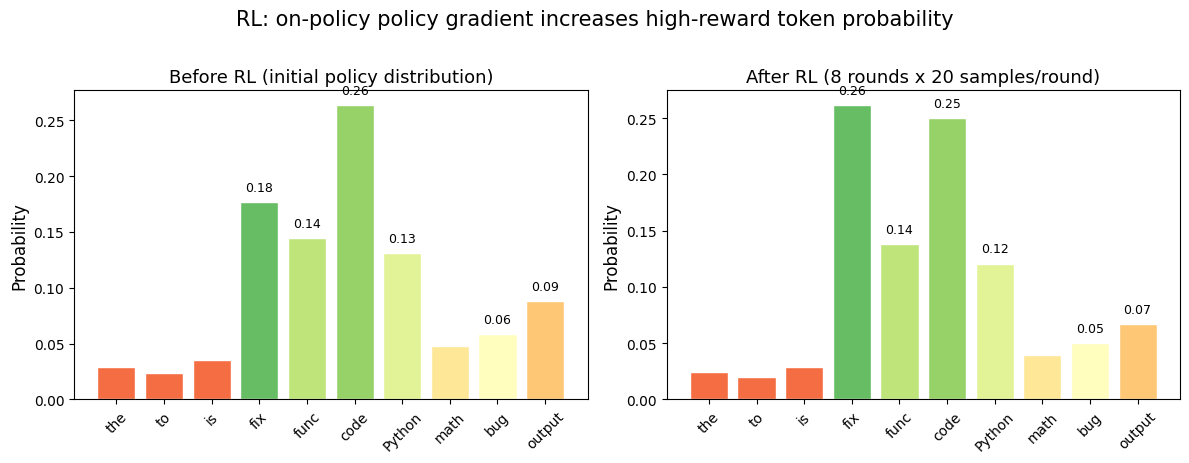

概率变化（按 reward 高低排列，绿=高价值，红=低价值）：
  fix    (reward=8): 0.177 → 0.262 (+0.085) ↑
  code   (reward=7): 0.264 → 0.250 (-0.014) ↓
  func   (reward=6): 0.145 → 0.138 (-0.007) ↓
  Python (reward=5): 0.131 → 0.121 (-0.010) ↓
  bug    (reward=4): 0.059 → 0.050 (-0.009) ↓
  math   (reward=3): 0.048 → 0.040 (-0.008) ↓
  output (reward=2): 0.088 → 0.067 (-0.021) ↓
  is     (reward=0): 0.036 → 0.029 (-0.007) ↓
  to     (reward=0): 0.024 → 0.020 (-0.004) →
  the    (reward=0): 0.029 → 0.024 (-0.005) ↓

→ on-policy：样本来自模型自己当前会生成的分布
→ 更新只发生在模型实际采样到的 token 上 → 不会把它拉到遥远的外部分布
→ 高 reward token 概率逐步上升，低 reward token 被压制
→ 但 reward 是结果级的（稀疏），模型不知道「哪一步」导致了好/坏结果


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# === RL：模拟 REINFORCE 策略梯度，从自身样本中筛选高 reward 行为 ===
print("=== RL：在模型自己生成的行为里筛选高 reward 方向 ===\n")

np.random.seed(42)

# 初始模型分布（对代码修复上下文）
init_logits = np.array([-1.0, -1.2, -0.8, 0.8, 0.6, 1.2, 0.5, -0.5, -0.3, 0.1])
init_probs = softmax(init_logits)

# 每个 token 的真实任务价值：代码是否正确、测试是否通过
true_reward = np.array([0, 0, 0, 8, 6, 7, 5, 3, 4, 2])  # 对应 vocab 顺序

# 模拟 REINFORCE: d(-log π(a) * R) / dlogits = -R * (one_hot(a) - π)
current_logits = init_logits.copy()
lr = 0.08
n_rounds = 8
n_samples = 20

history = [softmax(current_logits)]

for round_idx in range(n_rounds):
    probs = softmax(current_logits)
    gradient = np.zeros(vocab_size)
    
    for _ in range(n_samples):
        a = np.random.choice(vocab_size, p=probs)
        r = true_reward[a]
        # REINFORCE 梯度（负 reward 方向，因为要最小化负 reward）
        one_hot = np.zeros(vocab_size)
        one_hot[a] = 1
        gradient += -r * (one_hot - probs)
    
    gradient /= n_samples
    current_logits = current_logits - lr * gradient
    history.append(softmax(current_logits))

final_probs = history[-1]

# 可视化：RL 前 vs RL 后，按 reward 上色
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

reward_norm = (true_reward - true_reward.min()) / (true_reward.max() - true_reward.min() + 1e-10)
colors = [plt.cm.RdYlGn(0.2 + 0.6 * rn) for rn in reward_norm]

ax1.bar(vocab, init_probs, color=colors, edgecolor='white')
ax1.set_title('Before RL (initial policy distribution)', fontsize=13)
ax1.set_ylabel('Probability', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(init_probs):
    if v > 0.05:
        ax1.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

ax2.bar(vocab, final_probs, color=colors, edgecolor='white')
ax2.set_title(f'After RL ({n_rounds} rounds x {n_samples} samples/round)', fontsize=13)
ax2.set_ylabel('Probability', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(final_probs):
    if v > 0.05:
        ax2.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('RL: on-policy policy gradient increases high-reward token probability', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("概率变化（按 reward 高低排列，绿=高价值，红=低价值）：")
for i in np.argsort(true_reward)[::-1]:
    change = final_probs[i] - init_probs[i]
    direction = "↑" if change > 0.005 else ("↓" if change < -0.005 else "→")
    print(f"  {vocab[i]:6s} (reward={true_reward[i]}): "
          f"{init_probs[i]:.3f} → {final_probs[i]:.3f} ({change:+.3f}) {direction}")

print(f"\n→ on-policy：样本来自模型自己当前会生成的分布")
print(f"→ 更新只发生在模型实际采样到的 token 上 → 不会把它拉到遥远的外部分布")
print(f"→ 高 reward token 概率逐步上升，低 reward token 被压制")
print(f"→ 但 reward 是结果级的（稀疏），模型不知道「哪一步」导致了好/坏结果")

## OPD：在自身轨迹上接受教师纠偏

OPD 可以看作 SFT 与 RL 之间的一种组合。它像 SFT/蒸馏一样有 teacher signal，也像 RL 一样让训练数据来自 student 自己当前的生成分布。

核心流程是：student 自己生成回答 → teacher 在 student 生成的每个 prefix 上给出下一 token 的分布 → student 更新，使自己的分布更接近 teacher。

这一点和普通离线蒸馏完全不同：普通蒸馏是老师走一条标准路线，学生跟着学；OPD 是学生自己先走，走到哪里，老师就在哪里纠偏。

=== OPD：学生自己走，老师在学生走到的位置给密集指导 ===

1. Student 自回归生成 3 步：
   Step 1: 选了 'to' (最看好 'the')
   Step 2: 选了 'output' (最看好 'the')
   Step 3: 选了 'code' (最看好 'the')

2. Teacher 在每个 student prefix 上提供完整 token 分布：
   位置 0: 学生选了 'to'，老师最看好 'code'，KL(s||t) = 1.2624
   位置 1: 学生选了 'output'，老师最看好 'code'，KL(s||t) = 1.4356
   位置 2: 学生选了 'code'，老师最看好 'code'，KL(s||t) = 1.5641


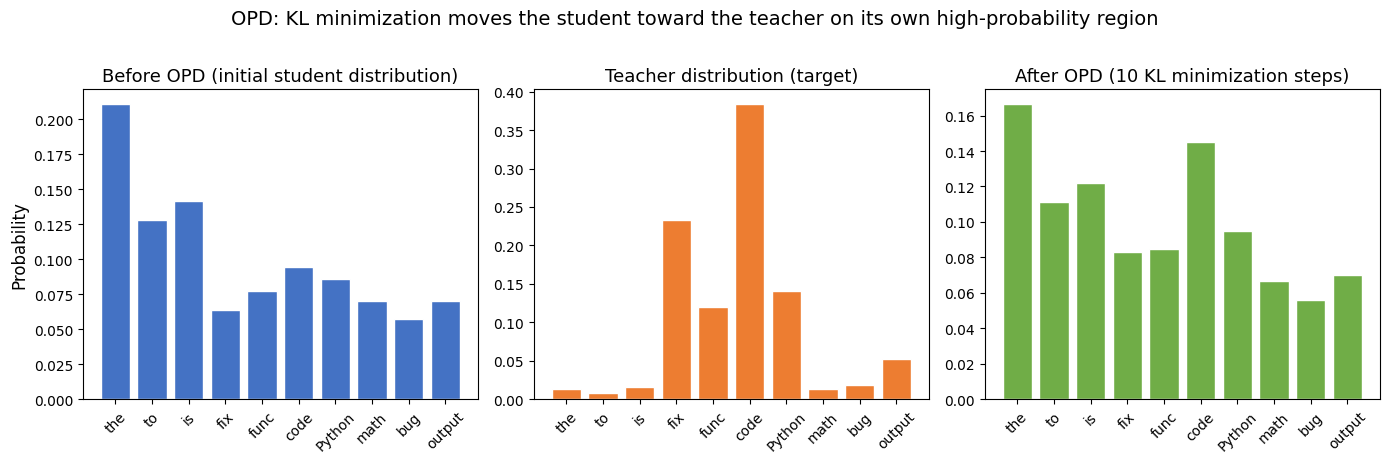


  总 KL loss = 4.2621

→ OPD 的特征：
  on-policy：prefix 来自 student 自己生成 → 训练分布在模型真实访问的区域
  dense signal：每个 token 位置都有 teacher 分布指导 → 不像 RL 只给结果 reward
  mode-seeking：KL(s||t) 只在 student 概率高的地方对齐 → 保留 student 擅长的模式
  比 SFT 更抗遗忘（数据来自自己的分布），比 RL 信号更密集（逐 token 指导）


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# === OPD：student 自己 rollout，teacher 在 student 的 prefix 上给 token 级纠偏 ===
print("=== OPD：学生自己走，老师在学生走到的位置给密集指导 ===\n")

np.random.seed(42)

# Student 模型——初始能力较弱，分布较分散
student_base_logits = np.array([0.7, 0.2, 0.3, -0.5, -0.3, -0.1, -0.2, -0.4, -0.6, -0.4])
# Teacher 模型——能力更强，分布更确定（温度更低）
teacher_base_logits = np.array([-0.5, -0.8, -0.4, 1.2, 0.8, 1.5, 0.9, -0.5, -0.3, 0.3])

s_probs = softmax(student_base_logits)
t_probs = softmax(teacher_base_logits / 0.6)  # teacher 温度更低 → 分布更尖锐

# 1. Student 自回归生成 3 步（模拟不同 prefix 下分布略有变化）
print("1. Student 自回归生成 3 步：")
seq = []
positions_logits = []
for step in range(3):
    # 每一步的 logits 在当前基础上略有偏移（模拟 prefix 变化）
    step_logits = student_base_logits + np.random.RandomState(step * 7).randn(vocab_size) * 0.4
    positions_logits.append(step_logits)
    step_probs = softmax(step_logits)
    tok_id = np.random.choice(vocab_size, p=step_probs)
    seq.append(tok_id)
    print(f"   Step {step+1}: 选了 '{vocab[tok_id]}' (最看好 '{vocab[np.argmax(step_probs)]}')")

# 2. Teacher 在每个 student prefix 上给逐 token 分布
print(f"\n2. Teacher 在每个 student prefix 上提供完整 token 分布：")
total_kl = 0
for t in range(3):
    s_p = softmax(positions_logits[t])
    t_p = softmax(teacher_base_logits / 0.6)
    kl = np.sum(s_p * (np.log(s_p + 1e-10) - np.log(t_p + 1e-10)))
    total_kl += kl
    print(f"   位置 {t}: 学生选了 '{vocab[seq[t]]}'，"
          f"老师最看好 '{vocab[np.argmax(t_p)]}'，"
          f"KL(s||t) = {kl:.4f}")

# 3. 模拟 OPD 梯度更新：最小化 KL(student || teacher)
# dKL(s||t)/ds_logits = s_probs - t_probs（当 t 固定时）
# 这是 OPD 的关键：把 student 分布拉向 teacher，但只在 student 当前概率高的位置
s_logits = student_base_logits.copy()
lr = 0.15
opd_steps = 10
opd_history = [softmax(s_logits)]

for step in range(opd_steps):
    s_p = softmax(s_logits)
    grad = s_p - t_probs           # KL(s||t) 对 s_logits 的梯度
    s_logits = s_logits - lr * grad  # 梯度下降
    opd_history.append(softmax(s_logits))

s_final = opd_history[-1]

# 可视化：Student 前 vs Teacher vs Student 后
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].bar(vocab, softmax(student_base_logits), color='#4472C4', edgecolor='white')
axes[0].set_title('Before OPD (initial student distribution)', fontsize=13)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(vocab, t_probs, color='#ED7D31', edgecolor='white')
axes[1].set_title('Teacher distribution (target)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(vocab, s_final, color='#70AD47', edgecolor='white')
axes[2].set_title(f'After OPD ({opd_steps} KL minimization steps)', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('OPD: KL minimization moves the student toward the teacher on its own high-probability region', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n  总 KL loss = {total_kl:.4f}")
print(f"\n→ OPD 的特征：")
print(f"  on-policy：prefix 来自 student 自己生成 → 训练分布在模型真实访问的区域")
print(f"  dense signal：每个 token 位置都有 teacher 分布指导 → 不像 RL 只给结果 reward")
print(f"  mode-seeking：KL(s||t) 只在 student 概率高的地方对齐 → 保留 student 擅长的模式")
print(f"  比 SFT 更抗遗忘（数据来自自己的分布），比 RL 信号更密集（逐 token 指导）")

## 三者核心区别

把 SFT、RL、OPD 放在一起看，核心区别不在于「有没有 teacher」或「有没有 reward」，而在于数据来源和信号密度。下面的表格从分布视角总结三者的关键差异。

=== 一张表：SFT vs RL vs OPD（从分布视角） ===

                              SFT                 RL                OPD        
----------------------------------------------------------------------------
训练数据来源                      外部标注数据集          student 自己生成       student 自己生成   
是否 on-policy                   否                  是                  是         
监督信号密度                    逐 token（密集）          结果级（稀疏）          逐 token（密集）    
目标来源                         标注答案分布         reward 定义的高价值    teacher 的 token 分布
分布移动方式                      整体拉向外部分布           在当前分布中筛选          在当前分布中局部纠偏    
优势                          冷启动、格式塑造          可验证任务、抗遗忘      on-policy + dense 
风险                          过度牵引、遗忘         reward 稀疏、成本高      teacher 信号可能有偏  

→ 三者不是替代关系，而是三种不同的「分布移动方式」


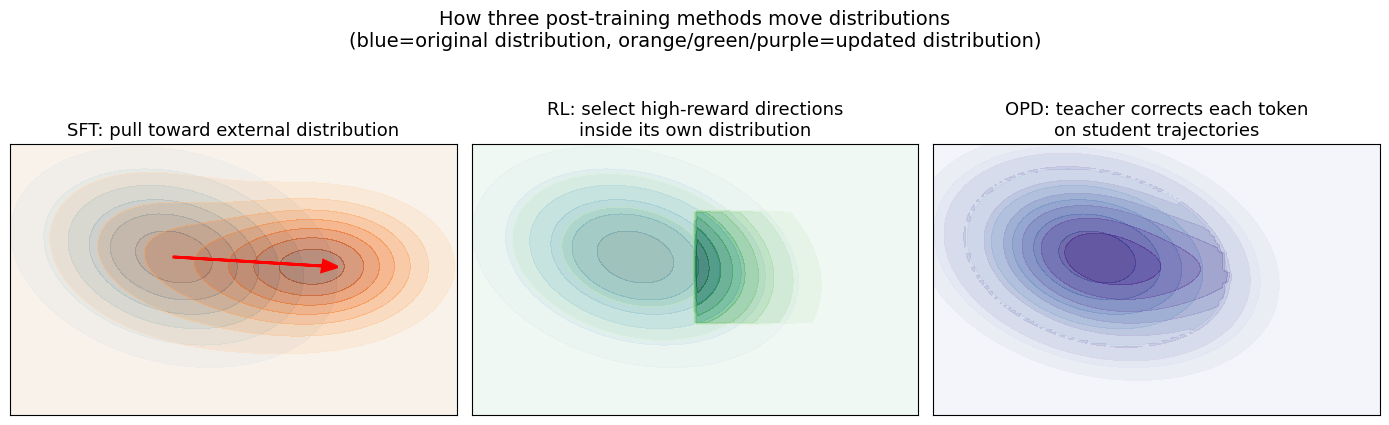


→ SFT：外部答案告诉模型「答案应该长这样」
→ RL：环境告诉模型「你自己的哪些行为更有价值」
→ OPD：老师告诉模型「你自己走到这里时，下一步应该怎么走」


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# === 三者核心区别：可视化对比 ===
print("=== 一张表：SFT vs RL vs OPD（从分布视角） ===\n")

header = f"{'':22} {'SFT':^18} {'RL':^18} {'OPD':^18}"
print(header)
print("-" * 76)

rows = [
    ("训练数据来源", "外部标注数据集", "student 自己生成", "student 自己生成"),
    ("是否 on-policy", "否", "是", "是"),
    ("监督信号密度", "逐 token（密集）", "结果级（稀疏）", "逐 token（密集）"),
    ("目标来源", "标注答案分布", "reward 定义的高价值", "teacher 的 token 分布"),
    ("分布移动方式", "整体拉向外部分布", "在当前分布中筛选", "在当前分布中局部纠偏"),
    ("优势", "冷启动、格式塑造", "可验证任务、抗遗忘", "on-policy + dense"),
    ("风险", "过度牵引、遗忘", "reward 稀疏、成本高", "teacher 信号可能有偏"),
]

for r in rows:
    print(f"{r[0]:22} {r[1]:^18} {r[2]:^18} {r[3]:^18}")

print(f"\n→ 三者不是替代关系，而是三种不同的「分布移动方式」")

# 可视化：用一个示意性的「分布热力图」来对比三种方法
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 构造一个 2D 示意分布网格（模拟 token 空间）
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# 原始模型分布（中心偏左上的高斯）
mu_orig = np.array([-0.8, 0.5])
sigma = np.array([[1.2, -0.3], [-0.3, 1.5]])
Z_orig = np.exp(-0.5 * ((X - mu_orig[0])**2 / sigma[0,0] 
                         + (Y - mu_orig[1])**2 / sigma[1,1]
                         - 2 * (X - mu_orig[0]) * (Y - mu_orig[1]) * sigma[0,1] / (sigma[0,0]*sigma[1,1])))

# —— SFT：整体拉向外部目标（右上） ——
mu_target = np.array([1.2, 0.3])
Z_target = np.exp(-0.5 * ((X - mu_target[0])**2 / 0.8 + (Y - mu_target[1])**2 / 0.8))
Z_sft = 0.3 * Z_orig + 0.7 * Z_target  # SFT 后：整体向目标偏移

ax = axes[0]
ax.contourf(X, Y, Z_orig, levels=8, cmap='Blues', alpha=0.5)
ax.contourf(X, Y, Z_sft, levels=8, cmap='Oranges', alpha=0.5)
ax.arrow(mu_orig[0], mu_orig[1], mu_target[0]-mu_orig[0], mu_target[1]-mu_orig[1],
         head_width=0.25, head_length=0.2, fc='red', ec='red', linewidth=2)
ax.set_title('SFT: pull toward external distribution', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

# —— RL：在原分布中筛选高 reward 子区域 ——
Z_rl = Z_orig.copy()
# 在 reward 高的区域（右上）增强信号
reward_mask = (X > 0) & (Y > -1) & (Y < 1.5)
Z_rl[reward_mask] *= 2.0
Z_rl[~reward_mask] *= 0.5
Z_rl = Z_rl / Z_rl.sum()

ax = axes[1]
ax.contourf(X, Y, Z_orig, levels=8, cmap='Blues', alpha=0.5)
ax.contourf(X, Y, Z_rl, levels=8, cmap='Greens', alpha=0.5)
ax.set_title('RL: select high-reward directions\ninside its own distribution', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

# —— OPD：在自身分布的高概率区局部纠偏 ——
Z_opd = Z_orig.copy()
# 在模型自身高概率区（中心附近）向 target 方向微调
local_mask = (Z_orig > Z_orig.max() * 0.3)
shift = Z_target * 0.3
Z_opd[local_mask] = Z_orig[local_mask] * 0.7 + shift[local_mask]
Z_opd = Z_opd / Z_opd.sum()

ax = axes[2]
ax.contourf(X, Y, Z_orig, levels=8, cmap='Blues', alpha=0.5)
ax.contourf(X, Y, Z_opd, levels=8, cmap='Purples', alpha=0.5)
ax.set_title('OPD: teacher corrects each token\non student trajectories', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('How three post-training methods move distributions\n'
             '(blue=original distribution, orange/green/purple=updated distribution)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print(f"\n→ SFT：外部答案告诉模型「答案应该长这样」")
print(f"→ RL：环境告诉模型「你自己的哪些行为更有价值」")
print(f"→ OPD：老师告诉模型「你自己走到这里时，下一步应该怎么走」")

In [6]:
import numpy as np

np.random.seed(42)

# 模拟词汇表
vocab = {"我": 0, "昨天": 1, "去了": 2, "学校": 3, "公园": 4, "超市": 5, "很": 6, "开心": 7, "无聊": 8, "累": 9}
id2token = {v: k for k, v in vocab.items()}
vocab_size = len(vocab)

def softmax(logits):
    logits = np.array(logits, dtype=np.float64)
    exp_logits = np.exp(logits - logits.max())
    return exp_logits / exp_logits.sum()

def log_softmax(logits):
    logits = np.array(logits, dtype=np.float64)
    m = logits.max()
    return logits - m - np.log(np.exp(logits - m).sum())

# 模拟学生模型：根据输入序列输出 logits
def student_model(input_ids):
    rng = np.random.RandomState(sum(input_ids) * 7 + 42)
    return rng.randn(vocab_size) * 2

# 模拟老师模型：更聪明、更确定
def teacher_model(input_ids):
    rng = np.random.RandomState(sum(input_ids) * 13 + 7)
    return rng.randn(vocab_size) * 1.2

print("词汇表和模型模拟函数准备完毕！")

词汇表和模型模拟函数准备完毕！


## 1. 知识蒸馏回顾

你有一个大模型（Teacher，老师）和一个小模型（Student，学生）。
目标是让小学生也能答出大学生水平的题。

```
Teacher (强模型，如 GPT-4 级别闭源模型或大开源模型): 输入 "1+1=?" → 输出 "2" ✅
Student (小模型, 0.5B 参数): 输入 "1+1=?" → 输出 "3" ❌

蒸馏目标: 让 Student 也输出 "2"
```

怎么做？两种思路：
- **离线蒸馏**：Teacher 先写一本「标准答案集」，Student 照着背
- **在线蒸馏（OPD）**：Student 先自己做题，Teacher 现场批改

## 2. 四种训练方式对比

只看两个问题就能分清所有方法：

1. **训练时的前缀（prefix）是谁写的？**
2. **学习目标（target）是谁给的？**

| 方法 | prefix 来源 | target 来源 | 类比 |
|:---|:---|:---|:---|
| **SFT** | 数据集标准答案 | 数据集标准答案 | 背课本 |
| **离线蒸馏** | Teacher 写好的固定前缀 | Teacher 的概率分布 | 背老师写的范文 |
| **OPD** | **Student 自己生成的前缀** | Teacher 在这个学生前缀上的分布 | 学生自己写，老师批改 |
| **OPSD** | **Student 自己生成的前缀** | 同一个模型的开卷版本 | 学生闭卷做题，开卷的自己来教 |

核心区别就是 prefix 那一列。OPD 和 OPSD 的 prefix 是学生自己写的，其他都是别人写好的。

## 3. 问题根源：Exposure Bias（暴露偏差）

这是理解 OPD 动机的关键概念之一。

```
训练时（SFT / 离线蒸馏）:
  前缀永远是标准答案的前半段
  比如: "我昨天去了" → 学预测 "学校"
  学生看到的前缀都是语法正确、语义通顺的

推理时（学生自己生成）:
  学生可能写出离谱的前缀
  比如: "我昨天很公园" → 现在要预测下一个词？
  学生从没见过 "我昨天很公园" 这种前缀！
  → 可能变得不稳定或继续偏离
```

**这就是 Exposure Bias**：训练时站在「正确轨道」上，推理时一旦走偏就进入未知领域。

就像你只在平坦的高速公路上练过车，第一次开到乡间土路就更容易出错。

In [7]:
import numpy as np

# 直观演示 Exposure Bias：用真实模型模拟训练 vs 推理的差异
print("=== Exposure Bias 演示 ===")
print()

# 训练时的前缀：标准答案的前半段
train_prefix = [0, 1, 2]  # "我昨天去了"
print(f"训练时的前缀: {[id2token[i] for i in train_prefix]} ← 数据集给的，语法正确")
t_logits = teacher_model(train_prefix)
t_probs = softmax(t_logits)
top3 = np.argsort(t_probs)[-3:][::-1]
print("  学生在这个前缀下被训练，老师最看好的 3 个词:")
for idx in top3:
    print(f"    '{id2token[idx]}': {t_probs[idx]:.3f}")
print()

# 推理时：学生自己生成，可能走偏
print("推理时，学生自回归生成:")
np.random.seed(99)
student_sequence = [0]  # "我"
for step in range(3):
    s_logits = student_model(student_sequence)
    s_probs = softmax(s_logits)
    next_token = np.random.choice(vocab_size, p=s_probs)
    student_sequence.append(next_token)
    print(f"  Step {step+1}: 输入 {[id2token[i] for i in student_sequence[:-1]]} "
          f"→ 采样到 '{id2token[next_token]}' (概率={s_probs[next_token]:.3f})")
print()

# 检查学生生成的离谱前缀下模型的困惑程度
weird_prefix = student_sequence[:-1]
s_logits_weird = student_model(weird_prefix)
s_probs_weird = softmax(s_logits_weird)
entropy = -np.sum(s_probs_weird * np.log(s_probs_weird + 1e-10))
print(f"学生生成的前缀: {[id2token[i] for i in weird_prefix]}")
print(f"  模型输出熵: {entropy:.3f} (越高越不确定)")
print(f"  最高概率的词: '{id2token[np.argmax(s_probs_weird)]}' ({np.max(s_probs_weird):.3f})")
print()
print("→ 学生从未在训练中见过这种前缀！输出非常不确定。")
print("→ Exposure Bias：训练和推理的 prefix 分布不一致。")

=== Exposure Bias 演示 ===

训练时的前缀: ['我', '昨天', '去了'] ← 数据集给的，语法正确
  学生在这个前缀下被训练，老师最看好的 3 个词:
    '昨天': 0.257
    '累': 0.164
    '去了': 0.157

推理时，学生自回归生成:
  Step 1: 输入 ['我'] → 采样到 '很' (概率=0.386)
  Step 2: 输入 ['我', '很'] → 采样到 '去了' (概率=0.518)
  Step 3: 输入 ['我', '很', '去了'] → 采样到 '去了' (概率=0.190)

学生生成的前缀: ['我', '很', '去了']
  模型输出熵: 1.019 (越高越不确定)
  最高概率的词: '昨天' (0.682)

→ 学生从未在训练中见过这种前缀！输出非常不确定。
→ Exposure Bias：训练和推理的 prefix 分布不一致。


## 4. OPD 的解决方案：在自己的轨迹上学习

OPD 的核心就三步：

```
Step 1: Student 自己生成一段回答（rollout）
  Prompt: "我昨天" → Student 生成: "我昨天去了公园很开心"

Step 2: Teacher 在 Student 的每个 prefix 上给反馈
  位置 2: prefix=[我, 昨天], Student 写了"去了" → Teacher: "还行"
  位置 3: prefix=[我, 昨天, 去了], Student 写了"公园" → Teacher: "可以"
  位置 4: prefix=[我, 昨天, 去了, 公园], Student 写了"很" → Teacher: "不太对"

Step 3: 根据 Teacher 的反馈更新 Student
  Teacher 认可的词 → 提高概率
  Teacher 不认可的词 → 降低概率
```

关键：Student 是在**自己真实写出来的轨迹**上被纠正的。
即使写出了「我昨天很公园」这种离谱前缀，Teacher 也会在这个离谱前缀上告诉它下一步该怎么走。
这样推理时遇到同样的离谱前缀，Student 就知道怎么办了。

In [8]:
import numpy as np

# 演示 OPD 的核心：Student 自己 rollout，Teacher 在 Student 的 prefix 上打分
print("=== OPD 核心流程演示 ===")
print()

prompt = [0, 1]  # "我昨天"
sequence = prompt.copy()
temperature = 1.0

print(f"Prompt: {[id2token[i] for i in prompt]}")
print()

# Step 1: Student rollout（学生自己写）
print("Step 1: Student 自回归生成")
for step in range(3):
    logits = student_model(sequence)
    probs = softmax(logits / temperature)
    next_token = np.random.choice(vocab_size, p=probs)
    sequence.append(next_token)
    print(f"  前缀={[id2token[i] for i in sequence[:-1]]} → 采样 {id2token[next_token]}")

print(f"\n生成序列: {[id2token[i] for i in sequence]}")
print()

# Step 2: Teacher 在每个位置打分
print("Step 2: Teacher 在 Student 自己的 prefix 上评估")
for t in range(len(prompt), len(sequence)):
    prefix = sequence[:t]
    sampled_token = sequence[t]
    
    s_logits = student_model(prefix)
    t_logits = teacher_model(prefix)
    s_logp = log_softmax(s_logits)[sampled_token]
    t_logp = log_softmax(t_logits)[sampled_token]
    
    advantage = t_logp - s_logp
    
    print(f"  位置 {t}: prefix={[id2token[i] for i in prefix]}")
    print(f"    Student 写了 '{id2token[sampled_token]}', 学生logp={s_logp:.3f}, 老师logp={t_logp:.3f}")
    print(f"    advantage = {advantage:+.3f} → {'✅ 加分' if advantage > 0 else '❌ 扣分'}")

print()
print("关键：不管 Student 写的是什么离谱内容，Teacher 都在这个真实的 prefix 上给反馈！")

=== OPD 核心流程演示 ===

Prompt: ['我', '昨天']

Step 1: Student 自回归生成
  前缀=['我', '昨天'] → 采样 去了
  前缀=['我', '昨天', '去了'] → 采样 很
  前缀=['我', '昨天', '去了', '很'] → 采样 公园

生成序列: ['我', '昨天', '去了', '很', '公园']

Step 2: Teacher 在 Student 自己的 prefix 上评估
  位置 2: prefix=['我', '昨天']
    Student 写了 '去了', 学生logp=-3.118, 老师logp=-2.268
    advantage = +0.850 → ✅ 加分
  位置 3: prefix=['我', '昨天', '去了']
    Student 写了 '很', 学生logp=-2.144, 老师logp=-2.923
    advantage = -0.779 → ❌ 扣分
  位置 4: prefix=['我', '昨天', '去了', '很']
    Student 写了 '公园', 学生logp=-0.636, 老师logp=-5.154
    advantage = -4.518 → ❌ 扣分

关键：不管 Student 写的是什么离谱内容，Teacher 都在这个真实的 prefix 上给反馈！


## 5. 数学本质：Forward KL vs Reverse KL

离线蒸馏和 OPD 的差异，可以用 KL 散度的**方向**来理解。

KL 散度衡量两个分布的「距离」，但它**不对称**：

$$D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$$

就像「从家到学校」和「从学校到家」虽然路程一样，但上下坡的感受完全不同。

**Forward KL（离线蒸馏）**：

$$D_{KL}(P_{Teacher} \| P_{Student})$$

- 期望在 Teacher 的分布下取：Teacher 觉得重要的地方，Student 必须学好
- 行为：**Mode-Covering** — Teacher 的所有「模式」Student 都要覆盖
- 问题：小模型容量有限时，强行覆盖 teacher 的所有模式可能导致每个模式都学得不够好，输出更平均化

**Reverse KL（OPD）**：

$$D_{KL}(P_{Student} \| P_{Teacher})$$

- 期望在 Student 的分布下取：Student 自己常去的地方，才需要向 Teacher 对齐
- 行为：**Mode-Seeking** — Student 只需要找到 Teacher 认可的、自己能稳定生成的模式
- 直觉：reverse KL 更偏 mode-seeking，小模型可以优先对齐自己常走、teacher 也认可的模式；但这也可能牺牲多样性。

In [9]:
import numpy as np

# 用真实概率分布演示 Forward KL vs Reverse KL
print("=== Forward KL vs Reverse KL 直觉 ===")
print()

# 模拟 Teacher 的三种风格概率分布
teacher_probs = np.array([0.40, 0.35, 0.25])
styles = ["学术严谨风", "幽默风趣风", "简洁直接风"]

print("Teacher 认为好答案有三种风格:")
for i, (style, prob) in enumerate(zip(styles, teacher_probs)):
    bar = "█" * int(prob * 40)
    print(f"  {style}: {prob:.0%} {bar}")
print()

# Forward KL (离线蒸馏): Student 被要求覆盖所有模式
# 用一个"平均化"的 Student 分布来展示
student_avg_probs = np.array([0.33, 0.33, 0.34])  # 均匀化
forward_kl = np.sum(teacher_probs * (np.log(teacher_probs + 1e-10) - np.log(student_avg_probs + 1e-10)))

print("Forward KL (离线蒸馏) — Student 试图覆盖所有模式:")
for i, (style, prob) in enumerate(zip(styles, student_avg_probs)):
    bar = "█" * int(prob * 40)
    print(f"  {style}: {prob:.0%} {bar}")
print(f"  Forward KL = {forward_kl:.4f}")
print(f"  → 输出变成四不像：'根据相关研究，哈哈，简单来说...'")
print()

# Reverse KL (OPD): Student 选择自己擅长的模式深耕
student_spec_probs = np.array([0.05, 0.85, 0.10])  # 专攻幽默风
reverse_kl = np.sum(student_spec_probs * (np.log(student_spec_probs + 1e-10) - np.log(teacher_probs + 1e-10)))

print("Reverse KL (OPD) — Student 专攻自己擅长的模式:")
for i, (style, prob) in enumerate(zip(styles, student_spec_probs)):
    bar = "█" * int(prob * 40)
    print(f"  {style}: {prob:.0%} {bar}")
print(f"  Reverse KL = {reverse_kl:.4f}")
print(f"  → 稳定、高质量的幽默回答")
print()

print(f"对比: Forward KL ({forward_kl:.4f}) vs Reverse KL ({reverse_kl:.4f})")
print("OPD 对小模型更友好：不需要面面俱到，专攻一门就够了！")

=== Forward KL vs Reverse KL 直觉 ===

Teacher 认为好答案有三种风格:
  学术严谨风: 40% ████████████████
  幽默风趣风: 35% ██████████████
  简洁直接风: 25% ██████████

Forward KL (离线蒸馏) — Student 试图覆盖所有模式:
  学术严谨风: 33% █████████████
  幽默风趣风: 33% █████████████
  简洁直接风: 34% █████████████
  Forward KL = 0.0207
  → 输出变成四不像：'根据相关研究，哈哈，简单来说...'

Reverse KL (OPD) — Student 专攻自己擅长的模式:
  学术严谨风: 5% ██
  幽默风趣风: 85% ██████████████████████████████████
  简洁直接风: 10% ████
  Reverse KL = 0.5586
  → 稳定、高质量的幽默回答

对比: Forward KL (0.0207) vs Reverse KL (0.5586)
OPD 对小模型更友好：不需要面面俱到，专攻一门就够了！


## 6. OPSD：不需要外部 Teacher 的 OPD

OPD 需要一个大 Teacher 模型，但 OPSD（On-Policy Self-Distillation）不需要——**Teacher 和 Student 是同一个模型，只是 Teacher 多看到了一些信息。**

```
OPSD 的核心设定:

Student (闭卷):  只看到题目
  → 自己写答案

Teacher (开卷):  同一个模型，但看到了标准答案/解题步骤
  → 在 Student 写的 prefix 上给出「如果我知道答案，我下一步会怎么写」

训练目标: 让闭卷的 Student 靠近开卷的 Teacher
→ 把「看答案才知道」的能力内化到「不看答案也能写」
```

**直觉**：做数学题时，看着答案你觉得「哦原来这样」，但合上答案就忘了。
OPSD 就是反复练「看着答案的自己」教「合上答案的自己」。

**局限**：如果 Teacher 多看的信息在测试时永远拿不到（比如每道题独有的标准解法），
OPSD 可能学到的只是「平均化的做题策略」，而不是真正的推理能力。
所以 OPSD 更适合把**共享规则**（格式偏好、系统提示）内化，而不是把**每道题独有的信息**内化。

## 7. 三种信号粒度：老师告诉你多少信息

Teacher 给反馈时，可以给不同「粒度」的信息：

| 粒度 | 老师告诉你什么 | 信息量 | 计算量 |
|:---|:---|:---|:---|
| **sampled-token** | 只告诉你「你选的这个词好不好」 | 最少 | 最小 |
| **top-k** | 告诉你「我心目中最好的 K 个词是哪些」 | 中等 | 中等 |
| **full-vocab** | 告诉你「整个词表每个词的概率」 | 最多 | 最大（32000 维！）|

```
sampled-token:  学生写了"公园" → Teacher: "还行，给 6 分"
top-k (k=5):    学生写了"公园" → Teacher: "最好的 5 个是: 学校(9分) 公园(6分) 超市(4分) 家(3分) 商场(2分)"
full-vocab:      学生写了"公园" → Teacher: "32000 个词各多少分..."
```

In [10]:
import numpy as np

# 对比三种粒度的 Teacher 反馈
prefix_demo = [0, 1, 2]  # "我昨天去了"

print("=== 三种信号粒度对比 ===")
print()

# Sampled-token: 只看选中的词
t_logits = teacher_model(prefix_demo)
t_logprobs = log_softmax(t_logits)
sampled_token = 3  # "学校"

print(f"1. sampled-token:")
print(f"   老师只告诉你 '{id2token[sampled_token]}' 的分数: {t_logprobs[sampled_token]:.3f}")
print(f"   其他 9 个词的情况你不知道")
print()

# Top-k: 看老师最看好的 K 个
k = 5
topk_idx = np.argsort(t_logprobs)[-k:][::-1]
print(f"2. top-{k}:")
for idx in topk_idx:
    print(f"   老师认为 '{id2token[idx]}' 分数: {t_logprobs[idx]:.3f}")
print()

# Full-vocab
print(f"3. full-vocab:")
print(f"   老师告诉你全部 {vocab_size} 个词的概率分布")
all_probs = softmax(t_logits)
for i, tok in id2token.items():
    bar = "█" * int(all_probs[i] * 40)
    print(f"   {tok:4s}: {all_probs[i]:.4f}  {bar}")

=== 三种信号粒度对比 ===

1. sampled-token:
   老师只告诉你 '学校' 的分数: -3.794
   其他 9 个词的情况你不知道

2. top-5:
   老师认为 '昨天' 分数: -1.357
   老师认为 '累' 分数: -1.806
   老师认为 '去了' 分数: -1.849
   老师认为 '我' 分数: -2.133
   老师认为 '公园' 分数: -2.340

3. full-vocab:
   老师告诉你全部 10 个词的概率分布
   我   : 0.1185  ████
   昨天  : 0.2573  ██████████
   去了  : 0.1575  ██████
   学校  : 0.0225  
   公园  : 0.0963  ███
   超市  : 0.0475  █
   很   : 0.0538  ██
   开心  : 0.0298  █
   无聊  : 0.0525  ██
   累   : 0.1643  ██████


## 8. 当只能用 sampled-token：KL 估计器

sampled-token 最省计算，但我们只有一个 token 的信息，却要估计整个分布的 KL 散度。怎么办？

真正的 Reverse KL 需要整个分布：

$$KL(P_S \| P_T) = \sum_i P_S(i) \cdot \log\frac{P_S(i)}{P_T(i)}$$

但现在我们只有一个采样出来的 token `y`。三种估计方法：

| 估计器 | 公式 | 特点 |
|:---|:---|:---|
| **k1** | $\log P_S(y) - \log P_T(y)$ | 无偏，但方差大，可为负 |
| **k2** | $\frac{1}{2}(\log P_S(y) - \log P_T(y))^2$ | 永远正数，有偏但稳定 |
| **k3** | $\frac{P_T(y)}{P_S(y)} - \log\frac{P_T(y)}{P_S(y)} - 1$ | 非负，常作为低方差替代估计器；是否适用要看采样分布和目标 |

In [11]:
import numpy as np

def k1_estimator(s_logp, t_logp):
    """直接差值：无偏但方差大，可为负"""
    return s_logp - t_logp

def k2_estimator(s_logp, t_logp):
    """平方近似：有偏但永远正数，方差小"""
    diff = s_logp - t_logp
    return 0.5 * diff * diff

def k3_estimator(s_logp, t_logp):
    """k3：非负、常作为低方差替代估计器（是否无偏取决于估计的目标和采样分布）"""
    ratio = t_logp - s_logp  # log(P_T / P_S)
    r = np.exp(ratio)         # P_T / P_S
    return r - ratio - 1

# 对比三种估计器
print("=== 三种 KL 估计器对比 ===")
print(f"{'学生logp':>10} {'老师logp':>10} {'k1':>10} {'k2':>10} {'k3':>10}  说明")
print("-" * 65)

cases = [
    (-0.5, -0.5, "完全一致"),
    (-1.0, -0.5, "老师更看好"),
    (-0.5, -1.0, "学生更看好"),
    (-2.0, -0.5, "差距大-老师看好"),
    (-0.5, -2.0, "差距大-学生看好"),
    (-3.0, -0.1, "极端差距"),
]

for s_lp, t_lp, desc in cases:
    k1 = k1_estimator(s_lp, t_lp)
    k2 = k2_estimator(s_lp, t_lp)
    k3 = k3_estimator(s_lp, t_lp)
    print(f"{s_lp:>+10.2f} {t_lp:>+10.2f} {k1:>+10.4f} {k2:>10.4f} {k3:>10.4f}  ← {desc}")

print()
print("k1 可为负 → 不适合直接当 loss")
print("k2 永远正数 → 有偏但稳定")
print("k3 非负，常作为更稳定的 KL 相关估计器；实际使用要确认采样分布和优化目标")

=== 三种 KL 估计器对比 ===
    学生logp     老师logp         k1         k2         k3  说明
-----------------------------------------------------------------
     -0.50      -0.50    +0.0000     0.0000     0.0000  ← 完全一致
     -1.00      -0.50    -0.5000     0.1250     0.1487  ← 老师更看好
     -0.50      -1.00    +0.5000     0.1250     0.1065  ← 学生更看好
     -2.00      -0.50    -1.5000     1.1250     1.9817  ← 差距大-老师看好
     -0.50      -2.00    +1.5000     1.1250     0.7231  ← 差距大-学生看好
     -3.00      -0.10    -2.9000     4.2050    14.2741  ← 极端差距

k1 可为负 → 不适合直接当 loss
k2 永远正数 → 有偏但稳定
k3 非负，常作为更稳定的 KL 相关估计器；实际使用要确认采样分布和优化目标


## 9. 完整 OPD 训练流程（串起来）

前面分别讲了 OPD 的各个组件：Student 自生成、Teacher 打分、Teacher 批改、Student 更新。现在把它们串成一次完整的训练迭代。

一次迭代的步骤是：取一个 prompt → Student 自己生成回答 → Teacher 对同一个 prompt 生成参考回答 → Teacher 比较两个回答给出逐句批注 → 将批注整理成 SFT 训练数据 → 更新 Student。下一轮迭代，Student 从更新后的参数出发重新生成，Teacher 再次批改。这个循环的关键在于：Student 每次都在自己犯错后的新状态下被纠正，而不是背别人的标准答案。

下面把整个循环写成一个可运行的训练 loop。

In [12]:
import numpy as np

def simulate_opd_training(prompt_ids, num_gen_tokens=3, mode="sampled_token_k3", topk=5):
    """模拟一次完整的 OPD 训练步骤"""
    
    # Step 1: Student rollout（学生自己生成）
    sequence = list(prompt_ids).copy()
    temp = 1.0
    
    print("Step 1: Rollout（学生自回归生成）")
    print(f"  Prompt: {[id2token[i] for i in prompt_ids]}")
    for step in range(num_gen_tokens):
        logits = student_model(sequence)
        probs = softmax(logits / temp)
        next_token = np.random.choice(vocab_size, p=probs)
        sequence.append(next_token)
    
    generated = sequence[len(prompt_ids):]
    print(f"  生成: {[id2token[i] for i in generated]}")
    
    # Step 2: 每个位置计算 OPD loss
    print(f"\nStep 2: 计算 OPD 损失 (模式: {mode})")
    total_loss = 0
    
    for t in range(len(prompt_ids), len(sequence)):
        prefix = sequence[:t]
        sampled_token = sequence[t]
        
        if mode == "sampled_token_k3":
            s_logp = log_softmax(student_model(prefix))[sampled_token]
            t_logp = log_softmax(teacher_model(prefix))[sampled_token]
            loss = k3_estimator(s_logp, t_logp)
            print(f"  位置{t}: '{id2token[sampled_token]}' | s_logp={s_logp:.3f} t_logp={t_logp:.3f} | k3={loss:.4f}")
        
        elif mode == "topk_rkl":
            t_logp = log_softmax(teacher_model(prefix))
            topk_idx = np.argsort(t_logp)[-topk:][::-1]
            t_renorm = softmax(t_logp[topk_idx])
            s_logp = log_softmax(student_model(prefix))
            s_renorm = softmax(s_logp[topk_idx])
            loss = np.sum(s_renorm * (np.log(s_renorm + 1e-10) - np.log(t_renorm + 1e-10)))
            print(f"  位置{t}: top-{topk}={[id2token[i] for i in topk_idx]} | RKL={loss:.4f}")
        
        total_loss += loss
    
    avg_loss = total_loss / len(generated)
    print(f"\n总损失: {total_loss:.4f} | 平均: {avg_loss:.4f}")
    print(f"→ 反传梯度，更新 Student → 下一轮 rollout → 循环")
    return avg_loss

np.random.seed(42)
print("### sampled_token + k3 模式 ###")
simulate_opd_training([0, 1], num_gen_tokens=3, mode="sampled_token_k3")

### sampled_token + k3 模式 ###
Step 1: Rollout（学生自回归生成）
  Prompt: ['我', '昨天']
  生成: ['学校', '超市', '超市']

Step 2: 计算 OPD 损失 (模式: sampled_token_k3)
  位置2: '学校' | s_logp=-0.803 t_logp=-5.509 | k3=3.7149
  位置3: '超市' | s_logp=-0.685 t_logp=-4.153 | k3=2.4994
  位置4: '超市' | s_logp=-2.903 t_logp=-4.291 | k3=0.6372

总损失: 6.8515 | 平均: 2.2838
→ 反传梯度，更新 Student → 下一轮 rollout → 循环


2.283848208244739

In [13]:
import numpy as np

np.random.seed(42)
print("### top-k Reverse KL 模式 ###")
simulate_opd_training([0, 1], num_gen_tokens=3, mode="topk_rkl", topk=5)

### top-k Reverse KL 模式 ###
Step 1: Rollout（学生自回归生成）
  Prompt: ['我', '昨天']
  生成: ['学校', '超市', '超市']

Step 2: 计算 OPD 损失 (模式: topk_rkl)
  位置2: top-5=['很', '我', '超市', '无聊', '累'] | RKL=1.4217
  位置3: top-5=['开心', '公园', '昨天', '去了', '无聊'] | RKL=0.5603
  位置4: top-5=['学校', '开心', '无聊', '我', '昨天'] | RKL=0.3147

总损失: 2.2966 | 平均: 0.7655
→ 反传梯度，更新 Student → 下一轮 rollout → 循环


0.7655468551277212

## 10. OPD 为什么现在才火

OPD 的思想不是新的，但过去很难落地——因为要在训练过程中反复做 Student rollout + Teacher 打分，工程复杂度远高于普通 SFT。

近年几类基础设施让这类方法更容易实验：

1. **训练 + 推理框架打通**：verl、vLLM、DeepSpeed 让 rollout、打分、梯度更新能流水线执行
2. **跨 tokenizer 蒸馏**：full-vocab KL 过去高度依赖同 tokenizer；现在可以用跨 tokenizer 对齐、top-k、sampled-token 或文本反馈等方式缓解，但仍有误差
3. **MoE 提供更强的 Teacher**：MoE 可能提高 teacher 的容量/计算性价比，也支撑了大规模在线采样和打分

注意：MoE 是**工程支撑**，不是 OPD 数学优势的来源。它让 Teacher 更强、更便宜，但不是「为什么 OPD 比离线蒸馏好」的理由。

## 11. 论文速览（截至 2026-05）

OPD 相关论文很多，下面只列已经能找到公开来源、且和本 notebook 主线直接相关的几篇。没有可靠链接的名字不要硬放进教程，否则读者无法复核。

| 论文 | 核心贡献 | 来源 |
|:---|:---|:---|
| **MiniLLM** (2023) | 用 reverse KL 做生成式 LM 蒸馏，是 OPD 思路的早期代表 | [arXiv](https://arxiv.org/abs/2306.08543) |
| **GKD** (2023/2024) | 统一 on-policy / off-policy 生成式蒸馏，强调学生生成分布上的学习 | [arXiv](https://arxiv.org/abs/2306.13649) |
| **Self-Distilled Reasoner / OPSD** (2026) | 同一模型用 privileged information 形成 teacher/student，做自蒸馏 | [arXiv](https://arxiv.org/abs/2605.18141) |
| **Pitfalls of On-Policy Self-Distillation** (2026) | 分析 OPSD 风险：teacher 分布不可靠、梯度不稳定、privileged info 难内化 | [arXiv](https://arxiv.org/abs/2605.11182) |
| **EDGE-OPD** (2026) | 用 early draft guidance 提高 on-policy distillation 效率 | [arXiv](https://arxiv.org/abs/2605.23493) |

共同结论：OPD/OPSD 不是银弹。真正优势是 **on-policy prefix + dense token-level feedback**；真正风险是 teacher 分布不可靠、privileged information 无法在测试时被重建。


## 12. 论文全景：怎么分类看 OPD

与其背一长串论文名，不如按“teacher 是谁、反馈有多细、目标是什么”来分类。这样看到新论文时，你能马上判断它在改哪一块。

#### 12.1 基础奠基（Foundations）

| 论文 | 核心贡献 | 来源 |
|:---|:---|:---|
| **MiniLLM** | Reverse-KL 框架用于生成式 LM 蒸馏 | [arXiv](https://arxiv.org/abs/2306.08543) |
| **GKD** | 混合 on-policy / off-policy 数据，允许不同散度目标 | [arXiv](https://arxiv.org/abs/2306.13649) |

#### 12.2 自蒸馏（Self-Distillation）

| 论文 | 核心贡献 | 来源 |
|:---|:---|:---|
| **Self-Distilled Reasoner / OPSD** | 同一模型的“开卷版”当 teacher，“闭卷版”当 student | [arXiv](https://arxiv.org/abs/2605.18141) |
| **Pitfalls of OPSD** | 说明 OPSD 可能学不会 privileged info，只是在训练时被 teacher 暂时扶住 | [arXiv](https://arxiv.org/abs/2605.11182) |

#### 12.3 效率与稳定性

| 论文 | 核心贡献 | 来源 |
|:---|:---|:---|
| **EDGE-OPD** | 在 rollout 早期用 teacher draft 做指导，提高训练效率 | [arXiv](https://arxiv.org/abs/2605.23493) |
| **ExOPD** | 把 OPD 看成带 KL 约束的强化学习式目标 | [arXiv](https://arxiv.org/abs/2602.12125) |

#### 12.4 工业实践里的对应形态

| 系统 | 相关做法 | 来源 |
|:---|:---|:---|
| **Gemma 2** | 把知识蒸馏作为预训练/后训练的重要组成部分 | [Gemma 2 paper](https://arxiv.org/abs/2408.00118) |
| **Qwen3** | 技术报告提到多阶段 post-training 与 distillation | [Qwen3 technical report](https://arxiv.org/abs/2505.09388) |

注意：GLM、MiMo、Nemotron、Baichuan、DeepSeek 系列等系统可能采用类似 on-policy / teacher-student 蒸馏技巧，但如果教程里点名某个系统，最好附官方论文、技术报告或模型卡。找不到来源时，不要把它写成确定事实；第三方解读只能作为线索。


## 13. 分类维度：从两个角度理解 OPD 生态

看 OPD 论文时，可以先问两个问题：**Teacher 是谁？目标是什么？**

#### 13.1 按 Teacher 类型

| Teacher 类型 | 你能拿到什么 | 典型路线 |
|:---|:---|:---|
| **外部白盒** | Teacher logits / top-k 概率 | MiniLLM、GKD 这类白盒蒸馏 |
| **外部黑盒** | 只能调用 API，拿不到 logits | 用采样答案、打分器或 reward model 近似 teacher 信号 |
| **自教师** | 同一个模型在 privileged context 下当 teacher | OPSD / self-distillation |
| **多 Teacher** | 多个专家模型或多个 checkpoint | 用于能力合并、压缩和持续学习 |

**关键决策：你能拿到 Teacher logits 吗？**
- 能 → 可以做白盒 KL 蒸馏，信号最密。
- 不能 → 走黑盒蒸馏、reward model 或自蒸馏路线。

#### 13.2 按主要目标

| 目标 | 典型用途 |
|:---|:---|
| **压缩 / 强到弱迁移** | 大模型教小模型 |
| **Post-RL 整合** | 把 RL 后的能力压回稳定模型 |
| **自蒸馏** | 不依赖外部 teacher，让模型的“开卷版”教“闭卷版” |
| **持续学习** | 把线上交互或新任务经验固化到权重里 |
| **效率优化** | 减少 teacher 调用、减少 rollout 成本 |

注意：同一个方法可能同时属于多个类别。比如 OPSD 既是自蒸馏，也可以用于推理能力压缩。


## 14. OPD 的工业落地

更稳妥的说法是：**OPD / on-policy teacher-student 思路已经开始进入 post-training 工程讨论和实验，但不同公司不会都用同一个名字公开它**。有的报告叫 distillation，有的叫 expert distillation，有的叫 self-distillation，有的只描述“student rollout + teacher feedback”。

| 系统 | 可确认的相关做法 | 读者应该怎么理解 |
|:---|:---|:---|
| **Gemma 2** | 公开论文明确讨论 knowledge distillation | KD 已经是训练小模型的重要手段 |
| **Qwen3** | 技术报告描述多阶段 post-training、thinking/non-thinking 与蒸馏相关流程 | distillation 用来把推理/通用能力压进统一模型 |

所以不要记成固定流水线 `SFT → RL → OPD`。更准确的工程图是：

```text
冷启动 / SFT
  → RL 或可验证任务训练
  → 采样、筛选、拒绝采样
  → 蒸馏 / 自蒸馏 / OPD，把能力压回目标模型
```

不同团队会按数据、算力、模型大小和部署目标调整顺序。OPD 的价值在于：让 Student 在自己的分布上走一遍，再让 Teacher 在这些真实会遇到的位置上给密集反馈。

参考：[Gemma 2 paper](https://arxiv.org/abs/2408.00118)、[Qwen3 technical report](https://arxiv.org/abs/2505.09388)。没有官方论文、技术报告或模型卡支撑的系统细节，只能作为线索，不能当官方训练流程。


## 15. 从训练到上线：模型格式与部署工具

前面的 OPD 解决了「怎么训练出好模型」的问题。训练完成后，下一个问题就是：**怎么把它部署出去？**

这一节覆盖从「训练好的模型」到「能用的服务」之间会遇到的三个实践问题：模型存储格式、去哪里找模型、用什么工具部署。

### 模型格式

训练好的模型权重需要保存到文件。不同格式有不同的设计目标：

| 格式 | 特点 | 常见场景 |
|:-----|:-----|:---------|
| **Safetensors** | 安全（不含可执行代码）、加载快 | HuggingFace 常用格式，GPU 训练/推理 |
| **GGUF** | 支持多种量化等级、单文件、CPU 友好 | llama.cpp / ollama 本地推理 |
| **ONNX** | 跨框架、跨平台 | 部署到手机/浏览器/嵌入式设备 |
| **PyTorch (.bin/.pt)** | PyTorch 原生格式 | 研究、调试 |

为什么 HuggingFace 推荐用 Safetensors 而不是 PyTorch 原生的 .bin？

- PyTorch 的 `.bin` 底层用 `pickle` 序列化，加载时会执行任意代码——恶意模型文件可以在你的机器上运行任意命令
- Safetensors 只存数值，不含可执行代码，所以更安全
- Safetensors 的加载速度也更快（零拷贝 mmap）

In [14]:
# 模型文件大小对比：同一模型，不同格式
# 以 Qwen2.5-7B 为例

params = 7e9  # 7B 参数

formats = [
    ("Safetensors (FP16)", params * 2 / 1e9, "GPU 训练/推理"),
    ("GGUF Q8_0", params * 1 / 1e9, "本地 CPU，高精度"),
    ("GGUF Q4_K_M", params * 0.56 / 1e9, "本地 CPU，平衡"),
    ("GGUF Q2_K", params * 0.31 / 1e9, "本地 CPU，省空间"),
    ("ONNX (FP16)", params * 2 / 1e9, "跨平台部署"),
]

print(f"Qwen2.5-7B 各格式大小:\n")
print(f"{'格式':<25} {'大小':>8} {'用途':<20}")
print("-" * 55)
for name, size_gb, usage in formats:
    print(f"{name:<25} {size_gb:>6.1f} GB  {usage}")

print(f"\n关键观察：GGUF Q4_K_M 把 7B 模型压到 ~4 GB，一张 8 GB 显存的卡就能跑")

Qwen2.5-7B 各格式大小:

格式                              大小 用途                  
-------------------------------------------------------
Safetensors (FP16)          14.0 GB  GPU 训练/推理
GGUF Q8_0                    7.0 GB  本地 CPU，高精度
GGUF Q4_K_M                  3.9 GB  本地 CPU，平衡
GGUF Q2_K                    2.2 GB  本地 CPU，省空间
ONNX (FP16)                 14.0 GB  跨平台部署

关键观察：GGUF Q4_K_M 把 7B 模型压到 ~4 GB，一张 8 GB 显存的卡就能跑


### HuggingFace：模型之家

[HuggingFace](https://huggingface.co) 是影响力很大的开源模型托管平台之一，许多开源 LLM 会在这里发布。

实际使用时会遇到的核心操作：

**1. 找模型**：搜索 → 看 Model Card（模型说明文档）→ 看 Benchmarks（评测分数）→ 看社区评价

**2. 理解命名规则**：
```
Qwen/Qwen2.5-7B-Instruct-GGUF
 │      │       │    │       └─ 格式（GGUF）
 │      │       │    └─ 变体（Instruct = 对话微调版）
 │      │       └─ 参数量（7B = 70 亿参数）
 │      └─ 模型系列（Qwen2.5）
 └─ 组织/作者（Qwen 团队）
```

**3. 下载**：直接用 `huggingface-cli download` 或代码中 `from_pretrained()` 自动下载

| 后缀 | 含义 |
|:-----|:-----|
| `Base` | 预训练基座，没有经过对话微调 |
| `Instruct` | 经过 SFT + RLHF，可以直接对话 |
| `Chat` | 同 Instruct，不同团队的叫法 |
| `GGUF` | 量化格式，用于 llama.cpp / ollama |
| `AWQ` / `GPTQ` | GPU 量化格式，用于 vLLM |

In [15]:
# 模拟：根据需求选择合适的模型文件

scenarios = [
    {
        "场景": "本地 Mac 上跑 7B 模型聊天",
        "推荐": "GGUF Q4_K_M + ollama",
        "理由": "ollama 一行命令安装，GGUF 对 Apple Silicon 友好，Q4_K_M 平衡精度和速度",
    },
    {
        "场景": "服务器上部署高并发 API",
        "推荐": "AWQ + vLLM",
        "理由": "vLLM 用 PagedAttention 做高吞吐，AWQ 在 GPU 上速度快精度高",
    },
    {
        "场景": "微调自己的模型",
        "推荐": "Safetensors (FP16) + QLoRA",
        "理由": "全精度基座 + LoRA 低秩微调，训练完合并回 Safetensors",
    },
    {
        "场景": "部署到手机端",
        "推荐": "ONNX + 量化",
        "理由": "ONNX 跨平台，手机端只能跑小模型（1-3B），需要极致压缩",
    },
]

print("=== 场景 → 推荐方案 ===\n")
for s in scenarios:
    print(f"场景: {s['场景']}")
    print(f"  推荐: {s['推荐']}")
    print(f"  理由: {s['理由']}")
    print()

=== 场景 → 推荐方案 ===

场景: 本地 Mac 上跑 7B 模型聊天
  推荐: GGUF Q4_K_M + ollama
  理由: ollama 一行命令安装，GGUF 对 Apple Silicon 友好，Q4_K_M 平衡精度和速度

场景: 服务器上部署高并发 API
  推荐: AWQ + vLLM
  理由: vLLM 用 PagedAttention 做高吞吐，AWQ 在 GPU 上速度快精度高

场景: 微调自己的模型
  推荐: Safetensors (FP16) + QLoRA
  理由: 全精度基座 + LoRA 低秩微调，训练完合并回 Safetensors

场景: 部署到手机端
  推荐: ONNX + 量化
  理由: ONNX 跨平台，手机端只能跑小模型（1-3B），需要极致压缩



### 部署工具选型

| 工具 | 定位 | 量化支持 | 适用场景 |
|:-----|:-----|:---------|:---------|
| **llama.cpp** | C++ 推理引擎 | GGUF | CPU / Apple Silicon / 单卡 GPU |
| **ollama** | llama.cpp 的简化包装 | GGUF | 本地开发、快速体验 |
| **vLLM** | GPU 高吞吐推理 | AWQ / GPTQ / FP16 | 生产环境、高并发 API |
| **SGLang** | 结构化生成优化 | 多种 | 需要严格 JSON 输出的场景 |
| **TensorRT-LLM** | NVIDIA 优化推理 | FP8 / INT8 | 追求极致性能的 GPU 部署 |

选择逻辑：
```
有没有 GPU？
  ├─ 没有 → llama.cpp / ollama（GGUF）
  └─ 有
      ├─ 追求吞吐量 → vLLM
      ├─ 追求结构化输出 → SGLang
      └─ 追求极致性能 → TensorRT-LLM
```

## 小结

### 分布视角：SFT、RL、OPD 的联系与区别（卷首）

1. ✅ **模型分布**：语言模型本质上是一个概率分布生成器——后训练就是在重塑这个分布
2. ✅ **SFT** = 向外部数据分布模仿：目标分布来自外部数据集，强在冷启动和格式塑造，弱在容易过度牵引
3. ✅ **RL** = 在自身行为中筛选高 reward 方向：样本来自模型自己生成（on-policy），更适合可验证任务，但 reward 稀疏
4. ✅ **OPD** = 学生自己走，老师在学生走到的位置纠偏：结合 on-policy 的相关性和蒸馏的 dense signal
5. ✅ **三者核心区别**：数据来源（外部 vs 自生成）、信号密度（密集 vs 稀疏）、分布移动方式（整体拉动 vs 局部筛选/纠偏）

### 核心原理（Sections 1-9）

6. ✅ **知识蒸馏** = 大模型教小模型
7. ✅ **离线蒸馏** = 背老师写的范文 → prefix 来自老师/数据集
8. ✅ **Exposure Bias** = 训练 prefix 和推理 prefix 不一致 → 推理时走偏就崩溃
9. ✅ **OPD** = Student 自己 rollout，Teacher 在 Student 的 prefix 上给反馈
10. ✅ **Forward KL**（离线蒸馏）= Mode-Covering → 小模型什么都学，什么都不精
11. ✅ **Reverse KL**（OPD）= Mode-Seeking → 小模型专攻一门
12. ✅ **OPSD** = 不需要外部 Teacher，同一个模型的开卷版教闭卷版
13. ✅ **三种粒度**：sampled-token < top-k < full-vocab
14. ✅ **三种 KL 估计器**：k1（无偏可为负）、k2（有偏永远正）、k3（无偏永远正，推荐）

### 工程与生态（Sections 10-15）

15. ✅ **工程基础设施**：verl + vLLM + DeepSpeed + 跨 tokenizer 对齐让 OPD 落地
16. ✅ **论文速览**：GKD / OPSD / Pitfalls / OGLS-SD 四篇核心论文
17. ✅ **论文全景**：按基础方法 / 自蒸馏 / 效率稳定性 / 工业实践来分类，比死记论文名更有用
18. ✅ **分类维度**：按 Teacher 类型（白盒/黑盒/自教师/上下文/多教师）和按目标（压缩/整合/持续学习/RL替代）
19. ✅ **工业落地**：Gemma 2 / Qwen3 等公开资料能看到蒸馏相关做法；OPD 相关系统要看是否有官方来源，但不要把所有系统都写成同一条固定流水线
20. ✅ **模型格式**：Safetensors（安全加载）、GGUF（量化推理）、ONNX（跨平台）
21. ✅ **HuggingFace**：开源模型的中心，理解命名规则是找模型的第一步
22. ✅ **部署工具**：无 GPU 可先看 llama.cpp/ollama，有 GPU 高吞吐常看 vLLM，NVIDIA 极致优化可看 TensorRT-LLM；最终按硬件和业务测试选择

### 一句话总结

SFT 是向外部数据分布模仿，RL 是在自己的行为里用 reward 筛选，OPD 是学生自己走、老师在学生走到的位置纠偏。

三者不是替代关系，而是三种不同的分布移动方式。离线蒸馏 = 背老师写的标准答案；OPD = 学生自己写，老师逐句批改。离线蒸馏可能遇到训练/推理 prefix 不一致；OPD 的优势是让 teacher 反馈更贴近 student 自己会访问的位置。

OPD 不是银弹——真正优势是 **on-policy prefix + dense token-level feedback**，真正风险是 **teacher 分布不可靠 + PI 无法内化**。
选哪条路取决于你的约束：有 logits → 白盒，只有 API → 黑盒，没有外部 teacher → 自蒸馏。

### 参考资料

- awesome-on-policy-distillation: https://github.com/chrisliu298/awesome-on-policy-distillation
- OPD Survey: https://arxiv.org/abs/2604.00626
- MiniLLM: https://arxiv.org/abs/2306.08543
- GKD: https://arxiv.org/abs/2306.13649
- ExOPD: https://arxiv.org/abs/2602.12125
- OPSD: https://arxiv.org/abs/2601.18734
- Pitfalls (Zhu et al.): https://arxiv.org/abs/2605.11182
- OGLS-SD: https://arxiv.org/abs/2605.12400
- Thinking Machines blog: https://thinkingmachines.ai/blog/on-policy-distillation/
- TRL DistillationTrainer: https://huggingface.co/docs/trl

## 作业> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：三种训练方法的分布移动方向**从分布视角理解 SFT、RL 和 OPD：- **SFT**：学生向外部数据分布 $p_{data}$ 模仿- **RL**：学生在自身生成分布上筛选高 reward 方向- **OPD**：学生在自身轨迹上接受 Teacher 纠偏分析以下说法是否正确：> "SFT 的训练数据来自外部数据集，因此训练时的输入分布（prompt 的来源）和推理时的分布可能不一致。OPD 让学生在自己生成的序列上学习，避免了这种分布不一致。"小提示：这就是 Exposure Bias 的核心——训练时看到的是「完美答案」，推理时看到的是「自己生成的（可能有错的）前文」。

In [16]:
# 作业 1：三种训练方法的分布移动方向# 判断说法是否正确answer = Trueassert answer is not None, "请填入 True 或 False"assert isinstance(answer, bool), "请填入 True 或 False"if answer == True:    print("✅ 作业 1 通过：")    print("   SFT 的 Exposure Bias：训练数据是人写的「完美前文」，")    print("   推理时模型看到的是「自己生成的（可能有错的）前文」，分布不一致。")    print("   OPD 在学生自己的轨迹上纠偏，训练和推理的输入分布一致，")    print("   从根本上缓解了 Exposure Bias。")else:    print("这个说法是正确的。")    print("提示：关注 SFT 训练时和推理时，模型看到的 prefix 分别来自哪里。")

**作业 2：Forward KL vs Reverse KL**KL 散度有两个方向，对应不同的优化行为：- **Forward KL**：$D_{KL}(P \| Q) = \sum P_i \log(P_i / Q_i)$，最小化它让 Q「覆盖」P 的所有模式（mean-seeking）- **Reverse KL**：$D_{KL}(Q \| P) = \sum Q_i \log(Q_i / P_i)$，最小化它让 Q「锁定」P 的某个模式（mode-seeking）假设 P 是一个双峰分布（两个高斯峰），Q 是单峰分布。画图分析 Forward KL 和 Reverse KL 分别会让 Q 的峰出现在哪里。小提示：Forward KL → Q 的峰会出现在 P 的两个峰之间（覆盖两个峰）；Reverse KL → Q 的峰会和 P 的某个峰对齐（锁定一个峰）。

In [17]:
# 作业 2：Forward KL vs Reverse KL# 选择正确的描述（填字母）answer = "C"# A) Forward KL 让 Student 分布更集中（mode-seeking）# B) Reverse KL 让 Student 分布覆盖 Teacher 的所有模式（mean-seeking）# C) Forward KL 更适合 SFT（希望 Student 学到 Teacher 的全部能力）# D) Reverse KL 和 Forward KL 的优化结果完全相同assert not answer.startswith("在这里"), "请先填入你的答案"assert answer in "ABCD", "请填入 A/B/C/D 中的一个字母"if answer == "C":    print("✅ 作业 2 通过：")    print("   Forward KL（mean-seeking）让 Student 尝试覆盖 Teacher 的所有输出模式，")    print("   即使某些模式概率很低也要覆盖到。")    print("   SFT 使用 Forward KL，希望 Student 全面学习 Teacher 的能力。")    print("   Reverse KL（mode-seeking）让 Student 集中在 Teacher 概率最高的区域，")    print("   适合 RL 场景（优化高 reward 方向），但可能遗漏长尾能力。")else:    print(f"你选了 {answer}。")    print("提示：Forward KL = 覆盖全面（适合学习），Reverse KL = 聚焦最优（适合优化）。")

**作业 3：KL 估计器对比**OPD 需要估计 KL 散度来控制学生分布不要偏离参考分布太远。三种常用的 KL 估计器：- $k_1$：无偏估计，但可以为负数- $k_2$：有偏，但永远为正- $k_3$：非负，比 $k_2$ 更稳定分析：为什么 KL 估计器可以为负数是一个问题？在训练中负的「KL 值」会导致什么后果？小提示：如果估计出的 KL 值为负，模型会以为自己和参考分布「非常接近」，于是放松约束，实际上可能已经偏离很远。

In [18]:
# 作业 3：KL 估计器对比# 选择最准确的解释（填字母）answer = "C"# A) KL 散度定义为非负，负值只是估计误差，对训练没有实际影响# B) 负的 KL 估计会欺骗 KL 惩罚机制，让模型误以为没有偏离参考模型，从而放松约束、越跑越偏# C) 只有 k1 会出现负值，但它的方差最小，所以实际训练中只用 k1 就够了# D) KL 估计器的偏差和方差对训练没有影响，关键在于学习率assert not answer.startswith("在这里"), "请先填入你的答案"assert answer in "ABCD", "请填入 A/B/C/D 中的一个字母"if answer == "B":    print("✅ 作业 3 通过：")    print("   KL 惩罚的作用：防止学生分布偏离参考分布太远。")    print("   如果估计值为负，惩罚失效，模型以为「还很近」，")    print("   实际上可能已经严重偏离（reward hacking）。")    print("   k2 和 k3 通过保证非负来避免这个问题，")    print("   代价是引入了一些偏差，但训练稳定性更重要。")else:    print(f"你选了 {answer}。")    print("提示：思考 KL 惩罚在训练中扮演什么角色——它是一个「安全绳」。")